In [50]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from kan import *


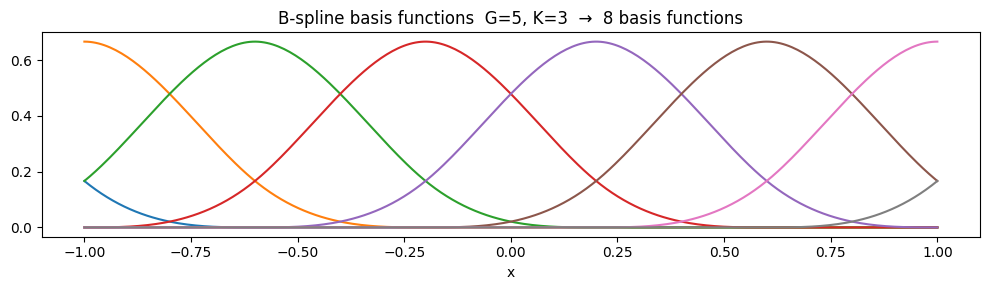

In [51]:
def visualize_basis(G=5, K=3, x_min=-1, x_max=1):
    h = (x_max - x_min) / G
    grid = torch.linspace(x_min - K*h, x_max + K*h, G + 2*K + 1)
    
    x = torch.linspace(x_min, x_max, 300).unsqueeze(-1)
    B = ((x >= grid[:-1]) & (x < grid[1:])).float()
    
    for k in range(1, K+1):
        left  = (x - grid[:-(k+1)]) / (grid[k:-1]   - grid[:-(k+1)] + 1e-8)
        right = (grid[(k+1):] - x)  / (grid[(k+1):] - grid[1:-k]    + 1e-8)
        B = left * B[..., :-1] + right * B[..., 1:]
    
    plt.figure(figsize=(10, 3))
    for i in range(B.shape[-1]):
        plt.plot(x.squeeze().numpy(), B[:, i].numpy())
    plt.title(f'B-spline basis functions  G={G}, K={K}  →  {G+K} basis functions')
    plt.xlabel('x')
    plt.tight_layout()
    plt.show()

visualize_basis(G=5, K=3)


In [52]:
class BSplineActivation(nn.Module):
    def __init__(self, num_features, G=5, K=3, x_min=-4.0, x_max=4.0):
        super().__init__()
        self.G = G
        self.K = K
        self.x_min = x_min
        self.x_max = x_max
        self.num_features = num_features

        h = (x_max - x_min) / G
        grid = torch.linspace(x_min - K*h, x_max + K*h, G + 2*K + 1)
        self.register_buffer('grid', grid)

        # Fix 1: small random noise instead of zeros (matches KAN)
        self.control_points = nn.Parameter(
            (torch.rand(num_features, G + K) - 0.5) * 0.5 / G
        )

    def _compute_basis(self, x):
        x = x.clamp(self.x_min, self.x_max).unsqueeze(-1)
        grid = self.grid
        B = ((x >= grid[:-1]) & (x < grid[1:])).float()
        B = torch.nan_to_num(B)  # Fix 2: handle NaN like KAN does
        for k in range(1, self.K + 1):
            left  = (x - grid[:-(k+1)]) / (grid[k:-1]   - grid[:-(k+1)] + 1e-8)
            right = (grid[(k+1):] - x)  / (grid[(k+1):] - grid[1:-k]    + 1e-8)
            B = left * B[..., :-1] + right * B[..., 1:]
            B = torch.nan_to_num(B)  # Fix 2: after every recursion step too
        return B  # (batch, num_features, G+K)

    def forward(self, x):
        B = self._compute_basis(x)
        return (B * self.control_points.unsqueeze(0)).sum(-1)


In [53]:
act = BSplineActivation(num_features=4, G=3, K=3)
dummy = torch.randn(8, 4)
out = act(dummy)

print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")           # should be (8, 4)
print(f"Params: {act.control_points.numel()}")  # should be 4 * (3+3) = 24


Input:  torch.Size([8, 4])
Output: torch.Size([8, 4])
Params: 24


In [54]:
class BSplineMLP(nn.Module):
    def __init__(self, width, G=5, K=3, x_min=-4.0, x_max=4.0):
        super().__init__()
        self.width   = width
        self.G       = G
        self.K       = K
        self.x_min   = x_min
        self.x_max   = x_max

        self.linears     = nn.ModuleList()
        self.activations = nn.ModuleList()

        for i in range(len(width) - 1):
            self.linears.append(nn.Linear(width[i], width[i+1]))
            if i < len(width) - 2:
                self.activations.append(
                    BSplineActivation(width[i+1], G, K, x_min, x_max)
                )

    def forward(self, x):
        for i, linear in enumerate(self.linears):
            x = linear(x)
            if i < len(self.activations):
                x = self.activations[i](x)
        return x

    def refine(self, new_G):
        # Build new model with finer grid
        new_model = BSplineMLP(self.width, G=new_G, K=self.K,
                               x_min=self.x_min, x_max=self.x_max)

        # Copy linear weights exactly — they don't need refinement
        for old_l, new_l in zip(self.linears, new_model.linears):
            new_l.weight.data.copy_(old_l.weight.data)
            new_l.bias.data.copy_(old_l.bias.data)

        # Refit each activation's control points to the finer grid
        with torch.no_grad():
            for old_act, new_act in zip(self.activations, new_model.activations):
                n = old_act.num_features

                # Sample x densely across the range
                x_s = torch.linspace(old_act.x_min, old_act.x_max, 4 * new_G + 1)
                # Expand to (samples, n_features) so all neurons are evaluated at once
                x_in = x_s.unsqueeze(1).expand(-1, n)  # (S, n)

                # Evaluate old spline at sample points
                y_old = old_act(x_in)  # (S, n)

                # Compute new basis at those same sample points
                B = new_act._compute_basis(x_in)   # (S, n, new_G+K)

                # Fit per neuron via least squares: B[s,j,:] @ coef[j,:] = y_old[s,j]
                # Rearrange to (n, S, new_G+K) and (n, S, 1)
                B_perm = B.permute(1, 0, 2)            # (n, S, new_G+K)
                y_perm = y_old.T.unsqueeze(-1)         # (n, S, 1)

                new_coef = torch.linalg.lstsq(B_perm, y_perm).solution.squeeze(-1)
                new_act.control_points.data.copy_(new_coef)

        return new_model


In [55]:
def count_kan_params(width, G, K):
    total = 0
    for i in range(len(width) - 1):
        d_in, d_out = width[i], width[i+1]
        total += (d_in * d_out) * (G + K + 3) + d_out
    return total

def count_bsmlp_params(width, G, K):
    total = 0
    for i in range(len(width) - 1):
        d_in, d_out = width[i], width[i+1]
        total += d_in * d_out + d_out            # linear layer
        if i < len(width) - 2:
            total += d_out * (G + K)             # bspline activation
    return total

# See the difference for G=3, K=3
G, K = 3, 3
print(f"KAN [4,2,1,1]:        {count_kan_params([4,2,1,1], G, K)} params")
print(f"BSplineMLP [4,4,4,1]: {count_bsmlp_params([4,4,4,1], G, K)} params")


KAN [4,2,1,1]:        103 params
BSplineMLP [4,4,4,1]: 93 params


In [56]:
def find_matching_width(target_params, G, K, d_in=4, d_out=1, n_hidden=2):
    best_h, best_diff = 1, float('inf')
    for h in range(1, 500):
        width = [d_in] + [h] * n_hidden + [d_out]
        diff = abs(count_bsmlp_params(width, G, K) - target_params)
        if diff < best_diff:
            best_diff, best_h = diff, h
        if count_bsmlp_params(width, G, K) > target_params * 2:
            break
    return best_h

# Check across all grid sizes
for G in [3, 5, 10, 20, 50]:
    kan_p = count_kan_params([4,2,1,1], G, K)
    h = find_matching_width(kan_p, G, K)
    bsmlp_p = count_bsmlp_params([4,h,h,1], G, K)
    print(f"G={G:2d}  KAN: {kan_p:4d} params  →  BSplineMLP h={h}: {bsmlp_p:4d} params")


G= 3  KAN:  103 params  →  BSplineMLP h=4:   93 params
G= 5  KAN:  125 params  →  BSplineMLP h=4:  109 params
G=10  KAN:  180 params  →  BSplineMLP h=5:  191 params
G=20  KAN:  290 params  →  BSplineMLP h=5:  291 params
G=50  KAN:  620 params  →  BSplineMLP h=5:  591 params


In [57]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

f = lambda x: torch.exp(
    (torch.sin(torch.pi * (x[:,[0]]**2 + x[:,[1]]**2)) +
     torch.sin(torch.pi * (x[:,[2]]**2 + x[:,[3]]**2))) / 2
)
dataset = create_dataset(f, n_var=4, train_num=3000, device=device)


In [58]:
def train_bsmlp(model, dataset, steps=50):
    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        history_size=10,
        line_search_fn="strong_wolfe",
        tolerance_grad=1e-32,
        tolerance_change=1e-32,
        max_iter=4
    )

    def closure():
        optimizer.zero_grad()
        pred = model(dataset['train_input'])
        loss = ((pred - dataset['train_label'])**2).mean()
        loss.backward()
        return loss

    for _ in range(steps):
        optimizer.step(closure)

    model.eval()
    with torch.no_grad():
        train_rmse = ((model(dataset['train_input']) - dataset['train_label'])**2).mean().sqrt().item()
        test_rmse  = ((model(dataset['test_input'])  - dataset['test_label'])**2).mean().sqrt().item()
    return train_rmse, test_rmse


In [59]:
grids = [3, 5, 10, 20, 50]
K = 3

# Pick a fixed width — use h=5 as a reasonable size
h = 5
width = [4, h, h, 1]

bsmlp_params   = []
bsmlp_test_rmse = []

# Step 1: initial train at G=3 (matches KAN's first cell)
model_bs = BSplineMLP(width, G=3, K=K).to(device)
_, test_rmse = train_bsmlp(model_bs, dataset, steps=20)
print(f"Initial G=3: RMSE={test_rmse:.4f}")

# Step 2: progressive refinement (matches KAN's refinement loop)
for G in grids:
    model_bs = model_bs.refine(new_G=G).to(device)
    _, test_rmse = train_bsmlp(model_bs, dataset, steps=50)
    p = count_bsmlp_params(width, G, K)
    bsmlp_params.append(p)
    bsmlp_test_rmse.append(test_rmse)
    print(f"G={G:2d} | params={p:4d} | test RMSE={test_rmse:.4f}")



Initial G=3: RMSE=0.5818
G= 3 | params= 121 | test RMSE=0.5818
G= 5 | params= 141 | test RMSE=0.3417
G=10 | params= 191 | test RMSE=0.3033
G=20 | params= 291 | test RMSE=0.3018
G=50 | params= 591 | test RMSE=0.2952


=== Parameter-Matched BSplineMLP ===
G= 3 | h=4 | params=  93 | RMSE=0.581844
G= 5 | h=4 | params= 109 | RMSE=0.581843
G=10 | h=5 | params= 191 | RMSE=0.137618
G=20 | h=5 | params= 291 | RMSE=0.322228
G=50 | h=5 | params= 591 | RMSE=0.182640

=== Progressive Refinement BSplineMLP ===
G= 3 | params= 121 | RMSE=0.581846
G= 5 | params= 141 | RMSE=0.581845
G=10 | params= 191 | RMSE=0.114380
G=20 | params= 291 | RMSE=0.101020
G=50 | params= 591 | RMSE=0.067074
=== BSplineMLP [4,2,1,1] — same architecture as KAN ===
G= 3 | params=  33 | RMSE=0.581842
G= 5 | params=  39 | RMSE=0.500563
G=10 | params=  54 | RMSE=0.416188
G=20 | params=  84 | RMSE=0.416930
G=50 | params= 174 | RMSE=0.417354


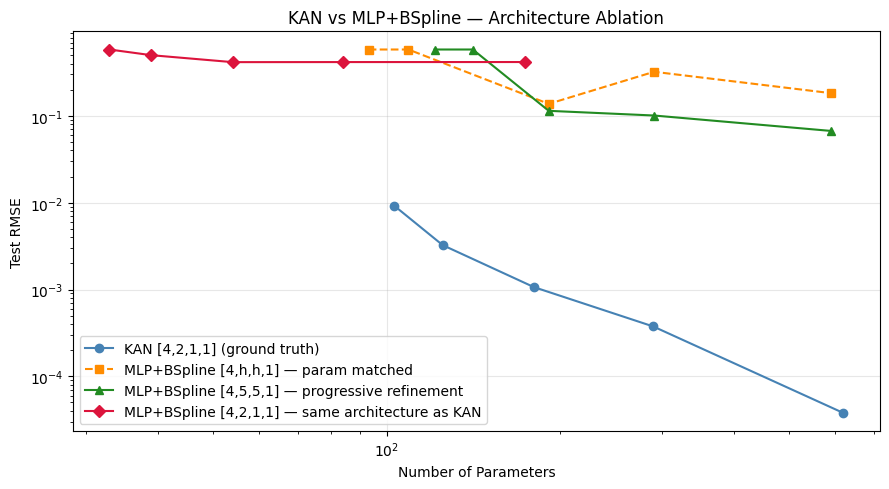

In [64]:
grids = [3, 5, 10, 20, 50]
K = 3

# ── 1. KAN ground truth (original notebook) ───────────────────────────────
kan_params    = [103, 125, 180, 290, 620]
kan_test_rmse = [0.009230, 0.003247, 0.001066, 0.0003754, 3.785e-05]

# ── 2. BSplineMLP — parameter matched (independent model per G) ────────────
matched_h          = [4, 4, 5, 5, 5]
bsmlp_matched_params = [93, 109, 191, 291, 591]
bsmlp_matched_rmse = []

print("=== Parameter-Matched BSplineMLP ===")
for i, G in enumerate(grids):
    h = matched_h[i]
    model_bs = BSplineMLP([4, h, h, 1], G=G, K=K).to(device)
    _, rmse = train_bsmlp(model_bs, dataset, steps=50)
    bsmlp_matched_rmse.append(rmse)
    print(f"G={G:2d} | h={h} | params={bsmlp_matched_params[i]:4d} | RMSE={rmse:.6f}")

# ── 3. BSplineMLP — progressive refinement (fixed h=5, warm start) ────────
bsmlp_progressive_params = [121, 141, 191, 291, 591]
bsmlp_progressive_rmse   = []

print("\n=== Progressive Refinement BSplineMLP ===")
model_prog = BSplineMLP([4, 5, 5, 1], G=3, K=K).to(device)
_, rmse = train_bsmlp(model_prog, dataset, steps=20)  # initial train

for G in grids:
    model_prog = model_prog.refine(new_G=G).to(device)
    _, rmse = train_bsmlp(model_prog, dataset, steps=50)
    bsmlp_progressive_rmse.append(rmse)
    p = count_bsmlp_params([4, 5, 5, 1], G, K)
    print(f"G={G:2d} | params={p:4d} | RMSE={rmse:.6f}")

# ── 4. BSplineMLP [4,2,1,1] — same architecture as KAN ───────────────────
def count_bsmlp_411_params(G, K=3):
    # Linear(4→2)+BSpline(2) + Linear(2→1)+BSpline(1) + Linear(1→1)
    return (4*2+2) + 2*(G+K) + (2*1+1) + 1*(G+K) + (1*1+1)

bsmlp_411_params = [count_bsmlp_411_params(G) for G in grids]
bsmlp_411_rmse   = []

print("=== BSplineMLP [4,2,1,1] — same architecture as KAN ===")
for G in grids:
    model_411 = BSplineMLP([4, 2, 1, 1], G=G, K=K).to(device)
    _, rmse = train_bsmlp(model_411, dataset, steps=50)
    bsmlp_411_rmse.append(rmse)
    print(f"G={G:2d} | params={count_bsmlp_411_params(G):4d} | RMSE={rmse:.6f}")



# ── Plot all four ──────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))

plt.plot(kan_params,              kan_test_rmse,            'o-',
         color='steelblue',   label='KAN [4,2,1,1] (ground truth)')

plt.plot(bsmlp_matched_params,   bsmlp_matched_rmse,        's--',
         color='darkorange',  label='MLP+BSpline [4,h,h,1] — param matched')

plt.plot(bsmlp_progressive_params, bsmlp_progressive_rmse,  '^-',
         color='forestgreen', label='MLP+BSpline [4,5,5,1] — progressive refinement')

plt.plot(bsmlp_411_params,       bsmlp_411_rmse,            'D-',
         color='crimson',     label='MLP+BSpline [4,2,1,1] — same architecture as KAN')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Parameters')
plt.ylabel('Test RMSE')
plt.title('KAN vs MLP+BSpline — Architecture Ablation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()